In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings("ignore")

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, roc_curve,
                             precision_recall_curve, ConfusionMatrixDisplay)
import joblib, os

# ════════════════════════════════════════════════════════════════
# THAM SỐ TOÀN CỤC
# ════════════════════════════════════════════════════════════════
PREDICTION_WINDOW_MONTHS  = 6    # Dự báo churn trong X tháng tới
OBSERVATION_WINDOW_MONTHS = 3    # Rolling window lấy behavioral features
N_SNAPSHOTS               = 12   # Số snapshot mỗi KH (tháng)
N_CUSTOMERS               = 5_000
RANDOM_SEED               = 42
PANEL_END                 = pd.Timestamp("2024-01-01")

np.random.seed(RANDOM_SEED)

SNAPSHOT_DATES = pd.date_range(
    end=PANEL_END,
    periods=N_SNAPSHOTS,
    freq="MS"
)

print(f"⚙️  Config:")
print(f"   KH unique        : {N_CUSTOMERS:,}")
print(f"   Snapshots/KH     : {N_SNAPSHOTS}")
print(f"   Prediction Window: {PREDICTION_WINDOW_MONTHS}M")
print(f"   Observation Window: {OBSERVATION_WINDOW_MONTHS}M")
print(f"   Panel: {SNAPSHOT_DATES[0].date()} → {SNAPSHOT_DATES[-1].date()}")
print(f"   Ước tính tổng dòng: ~{N_CUSTOMERS * N_SNAPSHOTS:,}")

⚙️  Config:
   KH unique        : 5,000
   Snapshots/KH     : 12
   Prediction Window: 6M
   Observation Window: 3M
   Panel: 2023-02-01 → 2024-01-01
   Ước tính tổng dòng: ~60,000


In [2]:
# ════════════════════════════════════════════════════════════════
# BƯỚC 1 — LOAD & TẠO KHÁCH HÀNG GỐC
#
# FIX CORE: churn_date phải phản ánh LOGIC kinh doanh thực sự
# Churn xảy ra sớm hơn khi KH có nhiều yếu tố rủi ro:
#   - Không active member
#   - Chỉ 1 sản phẩm (ít gắn kết)
#   - Balance = 0 (không có tài sản giữ lại)
#   - Tuổi trẻ (ít trung thành)
#   - CreditScore thấp (không ổn định tài chính)
#   - Tenure ngắn (chưa gắn kết)
#
# Mỗi yếu tố rủi ro → rút ngắn thời gian đến khi churn
# → Feature sau này sẽ "giải thích được" tại sao KH churn
# ════════════════════════════════════════════════════════════════
print("Đang load dataset gốc...")
base_df = pd.read_csv("data/Churn_Modelling.csv")
base_df = base_df.drop(columns=["RowNumber", "Surname", "Geography"])

customers = (base_df.drop(columns=["CustomerId"])
                    .sample(n=N_CUSTOMERS, replace=True)
                    .reset_index(drop=True))
customers["CustomerId"] = [f"CUST_{i+1:05d}" for i in range(N_CUSTOMERS)]

for col, lo, hi in [("CreditScore",350,850),("Age",18,92),
                    ("Tenure",0,10),("Balance",0,None),("EstimatedSalary",10000,None)]:
    customers[col] = (customers[col]
                      + np.random.normal(0, customers[col].std()*0.05, N_CUSTOMERS)
                      ).clip(lo, hi)
customers["NumOfProducts"] = customers["NumOfProducts"].round().clip(1,4).astype(int)
customers["Age"]     = customers["Age"].round(1)
customers["Tenure"]  = customers["Tenure"].clip(0,10).round(1)
customers["Balance"] = customers["Balance"].round(2)

join_days = np.random.randint(30, 3*365, N_CUSTOMERS)
customers["join_date"] = PANEL_END - pd.to_timedelta(join_days, unit="D")

# ── Tính CHURN RISK SCORE từ static attributes ───────────────────
# Mỗi yếu tố rủi ro cộng điểm → điểm cao = churn sớm hơn
risk = np.zeros(N_CUSTOMERS)
risk += (customers["IsActiveMember"] == 0).astype(float) * 3.0   # không active: +3
risk += (customers["NumOfProducts"]  == 1).astype(float) * 2.0   # 1 sản phẩm: +2
risk += (customers["Balance"]        == 0).astype(float) * 2.0   # không có tiền: +2
risk += (customers["Age"]            < 35).astype(float) * 1.0   # trẻ: +1
risk += (customers["Tenure"]         < 2 ).astype(float) * 1.5   # mới dùng: +1.5
risk += ((customers["CreditScore"]   < 500)).astype(float) * 1.0  # credit kém: +1
# risk ∈ [0, 10.5] — càng cao càng có nhiều yếu tố rủi ro

# ── Gán churn_date dựa trên risk score ───────────────────────────
# Base window: PREDICTION_WINDOW_MONTHS × 30 ngày
# risk cao → churn sớm hơn nhiều (trong vài tuần đầu sau PANEL_END)
# risk thấp → churn muộn hoặc không churn trong window
customers["churn_date"] = pd.NaT
# ── Convert risk → churn probability ─────────────────
prob = 1 / (1 + np.exp(-(risk - 3)))   # logistic transform

# scale về realistic churn rate
prob = prob * 0.4   # chỉnh để ra ~10–25%

prob = np.clip(prob, 0.02, 0.35)

# sample churn
customers["Exited"] = (np.random.rand(N_CUSTOMERS) < prob).astype(int)

mask = customers["Exited"] == 1

# Scale: risk 0 → churn sau ~180 ngày, risk 10 → churn sau ~15 ngày
# Dùng hàm nghịch đảo: days = max_days / (1 + risk * k)
max_days = PREDICTION_WINDOW_MONTHS * 30  # 180 ngày
k        = 0.4  # tốc độ giảm theo risk
churn_days_float = max_days / (1.0 + risk * k)

# Thêm noise ngẫu nhiên ±20% để không quá deterministic
noise   = np.random.uniform(0.80, 1.20, N_CUSTOMERS)
churn_days = (churn_days_float * noise).clip(1, max_days).astype(int)

customers.loc[mask, "churn_date"] = (
    PANEL_END + pd.to_timedelta(churn_days[mask.values], unit="D")
)

print(f"✅ {N_CUSTOMERS:,} KH unique | Exited: {mask.sum():,} ({mask.mean()*100:.1f}%)")
print(f"   join_date : {customers['join_date'].min().date()} → {customers['join_date'].max().date()}")
print(f"\nRisk score distribution (Exited=1):")
print(pd.Series(risk[mask.values]).describe().round(2).to_string())
print(f"\nChurn days distribution (Exited=1):")
print(pd.Series(churn_days[mask.values]).describe().round(0).to_string())


Đang load dataset gốc...
✅ 5,000 KH unique | Exited: 1,138 (22.8%)
   join_date : 2021-01-02 → 2023-12-02

Risk score distribution (Exited=1):
count    1138.00
mean        4.59
std         1.63
min         0.00
25%         3.00
50%         5.00
75%         6.00
max         9.50

Churn days distribution (Exited=1):
count    1138.0
mean       67.0
std        22.0
min        33.0
25%        53.0
50%        62.0
75%        76.0
max       180.0


In [3]:
# ════════════════════════════════════════════════════════════════
# BƯỚC 2 — TẠO PANEL DATA
#
# Mỗi (CustomerId × snapshot_date) = 1 dòng
# KH chỉ xuất hiện nếu đã join đủ OBSERVATION_WINDOW và chưa churn
# ════════════════════════════════════════════════════════════════

rows = []

for snap_date in SNAPSHOT_DATES:
    min_join = snap_date - pd.DateOffset(months=OBSERVATION_WINDOW_MONTHS)
    valid = customers[
        (customers["join_date"] <= min_join) &
        (customers["churn_date"].isna() | (customers["churn_date"] > snap_date))
    ].copy()

    if len(valid) == 0:
        continue

    valid["snapshot_date"]  = snap_date
    valid["snapshot_month"] = snap_date.month

    # Tenure: dùng continuous, không bucket
    valid["tenure_months"] = ((snap_date - valid["join_date"]) / pd.Timedelta(days=30.437)).round(1)

    # TARGET: will_churn trong PREDICTION_WINDOW_MONTHS tới
    prediction_cutoff = snap_date + pd.DateOffset(months=PREDICTION_WINDOW_MONTHS)
    valid["will_churn"] = np.where(
        valid["churn_date"].notna() & (valid["churn_date"] <= prediction_cutoff),
        1, 0
    ).astype(int)

    rows.append(valid)

panel_base = pd.concat(rows, ignore_index=True)

print(f"✅ Panel base: {len(panel_base):,} dòng")
print(f"   KH unique  : {panel_base['CustomerId'].nunique():,}")
print(f"   Snapshots  : {panel_base['snapshot_date'].nunique()}")
dist = panel_base["will_churn"].value_counts(normalize=True)*100
print(f"\n🎯 will_churn: Ở lại={dist.get(0,0):.1f}% | Churn={dist.get(1,0):.1f}%")

✅ Panel base: 47,375 dòng
   KH unique  : 4,737
   Snapshots  : 12

🎯 will_churn: Ở lại=90.6% | Churn=9.4%


In [4]:
# ════════════════════════════════════════════════════════════════
# BƯỚC 3 — SINH BEHAVIORAL SIGNALS
#
# NGUYÊN TẮC SỐNG CÒN:
#   - Không dùng future data (no leakage)
#   - Tất cả feature phải có tại thời điểm snapshot
#   - Phản ánh hành vi THAY ĐỔI, không phải giá trị tĩnh
#
# CẦN SINH:
#   [R] Recency   : days_since_last_login, days_since_last_txn
#   [T] Trend     : % change (có magnitude), slope thật
#   [D] Drop      : txn_current / avg_3m (tụt mạnh)
#   [B] Rolling   : avg_txn_3m, std_txn_3m
# ════════════════════════════════════════════════════════════════
df = panel_base.copy()
np.random.seed(RANDOM_SEED)

# ─────────────────────────────────────────────
# 1. SORT PANEL
# ─────────────────────────────────────────────
df = df.sort_values(["CustomerId", "snapshot_date"]).reset_index(drop=True)

# ─────────────────────────────────────────────
# 2. BASE BEHAVIOR PER CUSTOMER
# ─────────────────────────────────────────────
customer_base = df.groupby("CustomerId").agg({
    "IsActiveMember": "first",
    "Balance": "mean"
}).reset_index()

n_customers = len(customer_base)

customer_base["base_login"] = np.where(
    customer_base["IsActiveMember"] == 1,
    np.random.poisson(18, n_customers),
    np.random.poisson(5, n_customers)
)

customer_base["base_txn"] = np.where(
    customer_base["IsActiveMember"] == 1,
    np.random.poisson(12, n_customers),
    np.random.poisson(3, n_customers)
)

df = df.merge(customer_base[["CustomerId", "base_login", "base_txn"]],
              on="CustomerId", how="left")

# ─────────────────────────────────────────────
# 3. SEASONALITY + NOISE
# ─────────────────────────────────────────────
seasonal = 1.0 + 0.10 * np.sin(2 * np.pi * df["snapshot_month"] / 12)
df["noise"] = np.random.normal(0, 0.1, len(df))

# ─────────────────────────────────────────────
# 4. RAW COUNTS
# ─────────────────────────────────────────────
df["login_count_3m"] = (
    df["base_login"] * seasonal * (1 + df["noise"])
)

df["txn_count_3m"] = (
    df["base_txn"] * seasonal * (1 + df["noise"])
)

# ─────────────────────────────────────────────
# 5. SMOOTH TIME SERIES
# ─────────────────────────────────────────────
df["login_count_3m"] = (
    df.groupby("CustomerId")["login_count_3m"]
    .transform(lambda x: x.ewm(alpha=0.6).mean())
)

df["txn_count_3m"] = (
    df.groupby("CustomerId")["txn_count_3m"]
    .transform(lambda x: x.ewm(alpha=0.6).mean())
)

df["login_count_3m"] = df["login_count_3m"].clip(0, 90)
df["txn_count_3m"]   = df["txn_count_3m"].clip(0, 60)

# ─────────────────────────────────────────────
# 6. DECLINE GẦN CHURN (REALISTIC)
# ─────────────────────────────────────────────
days_to_churn = (df["churn_date"] - df["snapshot_date"]).dt.days

near_churn = (days_to_churn <= 60) & (df["will_churn"] == 1)

df.loc[near_churn, "txn_count_3m"] = (
    df.loc[near_churn, "txn_count_3m"] *
    np.random.uniform(0.2, 0.6, size=near_churn.sum())
)

df.loc[near_churn, "login_count_3m"] = (
    df.loc[near_churn, "login_count_3m"] *
    np.random.uniform(0.3, 0.7, size=near_churn.sum())
)

# ─────────────────────────────────────────────
# 7. FINALIZE COUNTS
# ─────────────────────────────────────────────
df["login_count_3m"] = df["login_count_3m"].round().astype(int)
df["txn_count_3m"]   = df["txn_count_3m"].round().astype(int)

# ─────────────────────────────────────────────
# 8. CREATE 1M (SAU DECLINE)
# ─────────────────────────────────────────────
df["login_count_1m"] = (
    df["login_count_3m"] / 3 *
    np.random.uniform(0.7, 1.3, len(df))
).clip(0).round().astype(int)

df["txn_count_1m"] = (
    df["txn_count_3m"] / 3 *
    np.random.uniform(0.7, 1.3, len(df))
).clip(0).round().astype(int)

# ─────────────────────────────────────────────
# 9. TREND
# ─────────────────────────────────────────────
txn_avg = (df["txn_count_3m"] / 3).replace(0, np.nan)
login_avg = (df["login_count_3m"] / 3).replace(0, np.nan)

df["txn_trend_pct"] = (
    (df["txn_count_1m"] - txn_avg) / (txn_avg + 0.5)
).clip(-1.5, 1.5).fillna(0)

df["login_trend_pct"] = (
    (df["login_count_1m"] - login_avg) / (login_avg + 0.5)
).clip(-1.5, 1.5).fillna(0)

# ─────────────────────────────────────────────
# 10. DROP RATIO
# ─────────────────────────────────────────────
df["txn_drop_ratio"] = (
    df["txn_count_1m"] / (txn_avg + 0.5)
).clip(0, 3).fillna(0)

df["login_drop_ratio"] = (
    df["login_count_1m"] / (login_avg + 0.5)
).clip(0, 3).fillna(0)

# ─────────────────────────────────────────────
# 11. RECENCY (SAU DROP)
# ─────────────────────────────────────────────
df["days_since_last_login"] = (
    30 / (df["login_count_1m"] + 1) *
    (1 + (df["login_drop_ratio"] < 0.7).astype(int) * 0.5)
).clip(1, 180).round().astype(int)

df["days_since_last_txn"] = (
    df["days_since_last_login"] +
    np.random.randint(0, 10, len(df))
).clip(1, 210)

# ─────────────────────────────────────────────
# 12. MONETARY
# ─────────────────────────────────────────────
df["avg_txn_amount_3m"] = (
    np.random.lognormal(7.2, 0.8, len(df)) *
    (1 + df["Balance"] / 200000)
).clip(10, 30000)

df["std_txn_amount_3m"] = (
    df["avg_txn_amount_3m"] *
    np.random.uniform(0.3, 0.7, len(df))
)

# ─────────────────────────────────────────────
# 13. BALANCE CHANGE
# ─────────────────────────────────────────────
df["balance_3m_ago"] = df.groupby("CustomerId")["Balance"].shift(1)

df["balance_change_pct"] = (
    (df["Balance"] - df["balance_3m_ago"]) /
    (df["balance_3m_ago"] + 1)
).fillna(0).clip(-1, 1)

# ─────────────────────────────────────────────
# 14. COMPLAINT
# ─────────────────────────────────────────────
df["complaint_count"] = np.random.poisson(
    0.3 + 1.2 * df["will_churn"]
)

# ─────────────────────────────────────────────
# 15. INTERACTIONS
# ─────────────────────────────────────────────
df["high_balance_low_txn"] = (
    (df["Balance"] > df["Balance"].median()) &
    (df["txn_count_3m"] < df["txn_count_3m"].quantile(0.25))
).astype(int)

df["complaint_and_inactive"] = (
    (df["complaint_count"] > 0) &
    (df["IsActiveMember"] == 0)
).astype(int)

print("✅ B3 DONE — CLEAN & CONSISTENT")

# ─────────────────────────────────────────────
# DONE
# ─────────────────────────────────────────────
print("✅ Behavioral features (REALISTIC) DONE")
print(f"Rows: {len(df):,}")

print("\n📊 Check recency:")
print(df.groupby("will_churn")["days_since_last_login"].mean())

print("\n📊 Check drop ratio:")
print(df.groupby("will_churn")["txn_drop_ratio"].mean())


✅ B3 DONE — CLEAN & CONSISTENT
✅ Behavioral features (REALISTIC) DONE
Rows: 47,375

📊 Check recency:
will_churn
0     9.760903
1    14.139744
Name: days_since_last_login, dtype: float64

📊 Check drop ratio:
will_churn
0    0.751709
1    0.625482
Name: txn_drop_ratio, dtype: float64


In [5]:
# ════════════════════════════════════════════════════════════════
# BƯỚC 4 — FEATURE ENGINEERING CUỐI
#
# NGUYÊN TẮC:
#   GIỮ nếu: ý nghĩa hành vi rõ, continuous, không trùng
#   LOẠI nếu: flag 0/1, combo thủ công, trùng logic
#
# NHÓM GIỮ:
#   ✅ Core behavior  : recency, drop, trend, rolling
#   ✅ Profile        : Age, Tenure (continuous), Balance, IsActiveMember
#   ✅ Ratio          : spend_to_income, balance_to_salary
#   ✅ Interaction    : chỉ 2 cái có ý nghĩa rõ
#
# NHÓM LOẠI:
#   ❌ *_flag (yếu, trùng với continuous)
#   ❌ age_group, tenure_group (mất thông tin, dùng Age/Tenure thay)
#   ❌ snapshot_quarter, snapshot_year (ít liên quan trực tiếp)
#   ❌ combo feature phức tạp (overfit)
# ════════════════════════════════════════════════════════════════

# ── Ratio features ─────────────────────────────────────────────
df["balance_to_salary"] = np.log1p(df["Balance"]) / (df["EstimatedSalary"] + 1).round(4)

df["login_per_day_3m"] = (df["login_count_3m"] / 90).round(4)

df["spend_to_income"] = (
    df["avg_txn_amount_3m"] * df["txn_count_3m"] / (df["EstimatedSalary"] / 4 + 1)
).clip(0, 10).round(4)

print("✅ Feature engineering hoàn tất")
print(f"\nCác features sẽ dùng:")
preview_features = [
    # [R] Recency
    "days_since_last_login", "days_since_last_txn",
    # [T] Trend (có magnitude)
    "txn_trend_pct", "login_trend_pct",
    # [D] Drop
    "txn_drop_ratio", "login_drop_ratio",
    # [B] Rolling
    "txn_count_3m", "avg_txn_amount_3m", "std_txn_amount_3m",
    "login_count_3m", "login_per_day_3m",
    # Balance
    "balance_change_pct",
    # Profile
    "Age", "tenure_months", "Balance", "NumOfProducts", "IsActiveMember",
    # Ratio
    "balance_to_salary", "spend_to_income",
    # Complaint
    "complaint_count",
    # Interaction (2 cái ý nghĩa rõ)
    "high_balance_low_txn", "complaint_and_inactive",
    # Categorical
    "Gender",
]
for f in preview_features:
    if f in df.columns:
        print(f"   ✅ {f}")
    else:
        print(f"   ❌ THIẾU: {f}")

✅ Feature engineering hoàn tất

Các features sẽ dùng:
   ✅ days_since_last_login
   ✅ days_since_last_txn
   ✅ txn_trend_pct
   ✅ login_trend_pct
   ✅ txn_drop_ratio
   ✅ login_drop_ratio
   ✅ txn_count_3m
   ✅ avg_txn_amount_3m
   ✅ std_txn_amount_3m
   ✅ login_count_3m
   ✅ login_per_day_3m
   ✅ balance_change_pct
   ✅ Age
   ✅ tenure_months
   ✅ Balance
   ✅ NumOfProducts
   ✅ IsActiveMember
   ✅ balance_to_salary
   ✅ spend_to_income
   ✅ complaint_count
   ✅ high_balance_low_txn
   ✅ complaint_and_inactive
   ✅ Gender


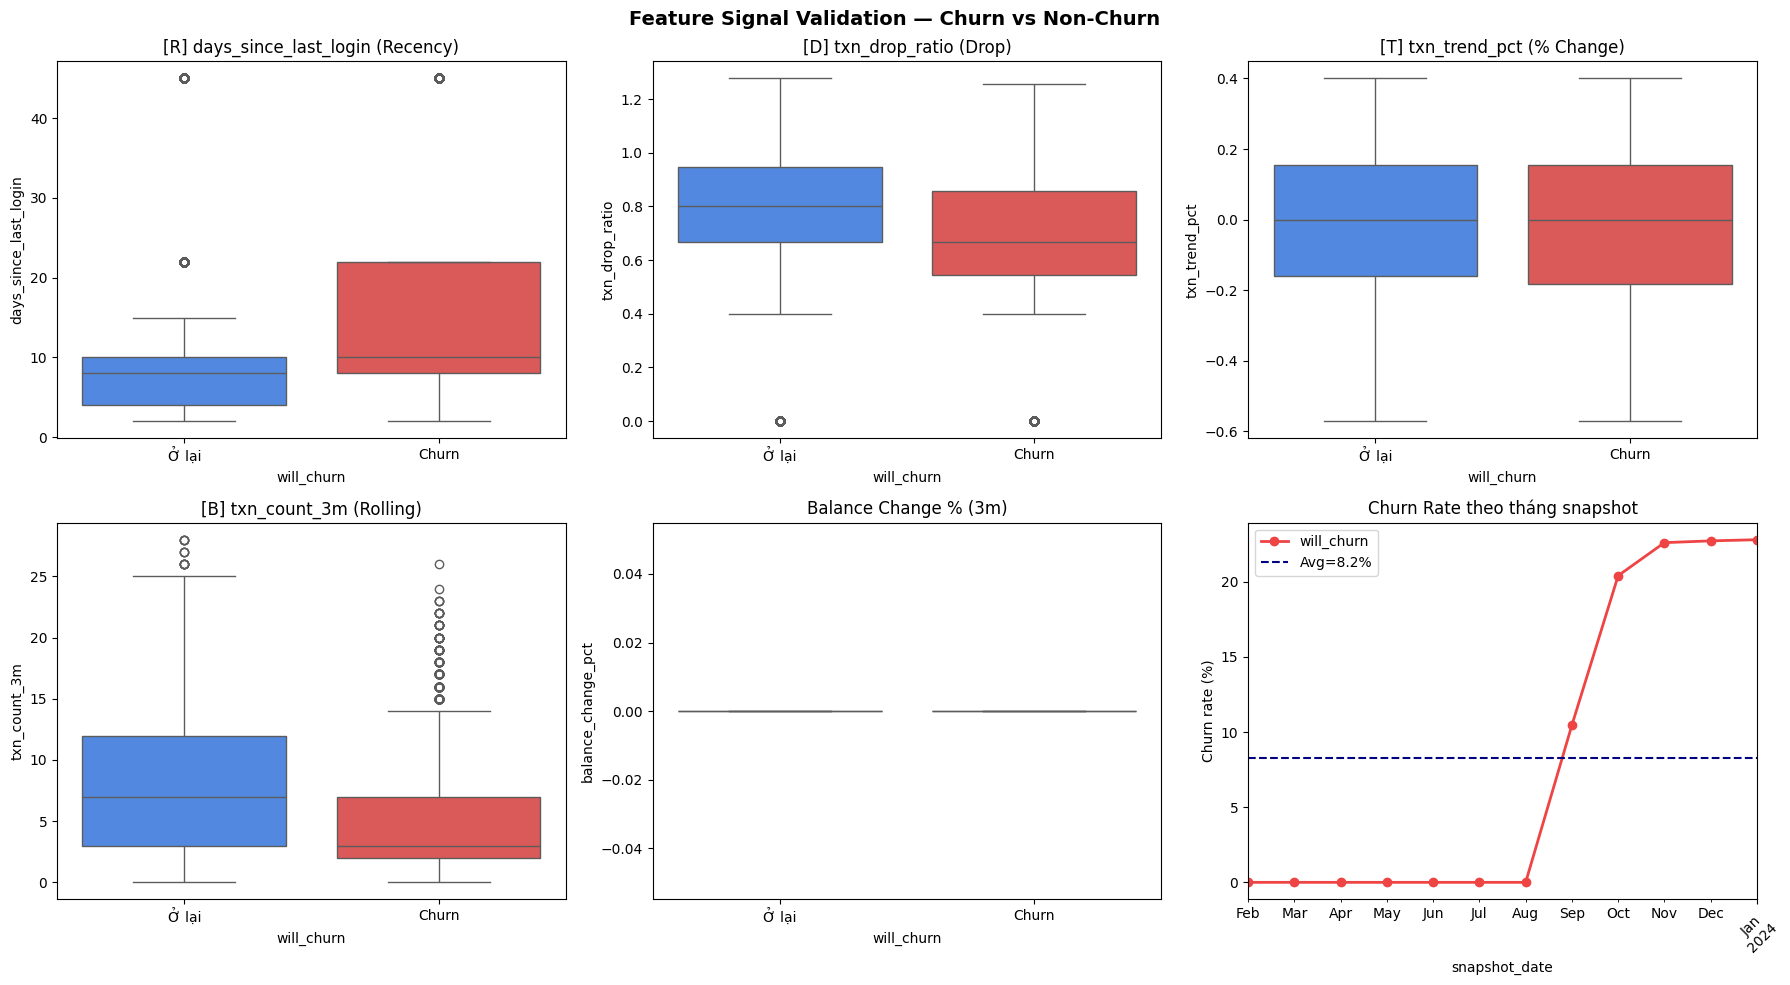


=== TOP 15 FEATURES TƯƠNG QUAN VỚI will_churn ===
Exited                    0.5896
complaint_count           0.4752
complaint_and_inactive    0.3624
login_per_day_3m          0.1694
login_count_3m            0.1694
IsActiveMember            0.1650
login_count_1m            0.1600
txn_count_3m              0.1561
days_since_last_login     0.1538
txn_count_1m              0.1500
base_login                0.1478
days_since_last_txn       0.1453
base_txn                  0.1355
txn_drop_ratio            0.1203
login_drop_ratio          0.0952


In [6]:
# ════════════════════════════════════════════════════════════════
# BƯỚC 5 — EDA: VALIDATE SIGNAL CỦA FEATURE
#
# Mục tiêu: xác nhận feature phân biệt được churn vs non-churn
# ════════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Feature Signal Validation — Churn vs Non-Churn", fontsize=14, fontweight="bold")

# 5.1 days_since_last_login (Recency — quan trọng nhất)
sns.boxplot(x="will_churn", y="days_since_last_login", data=df,
            hue="will_churn", palette=["#3b82f6","#ef4444"],
            legend=False, ax=axes[0,0])
axes[0,0].set_title("[R] days_since_last_login (Recency)")
axes[0,0].set_xticklabels(["Ở lại","Churn"])

# 5.2 txn_drop_ratio (Drop signal)
sns.boxplot(x="will_churn", y="txn_drop_ratio", data=df,
            hue="will_churn", palette=["#3b82f6","#ef4444"],
            legend=False, ax=axes[0,1])
axes[0,1].set_title("[D] txn_drop_ratio (Drop)")
axes[0,1].set_xticklabels(["Ở lại","Churn"])

# 5.3 txn_trend_pct (Trend có magnitude)
sns.boxplot(x="will_churn", y="txn_trend_pct", data=df,
            hue="will_churn", palette=["#3b82f6","#ef4444"],
            legend=False, ax=axes[0,2])
axes[0,2].set_title("[T] txn_trend_pct (% Change)")
axes[0,2].set_xticklabels(["Ở lại","Churn"])

# 5.4 txn_count_3m (Rolling behavior)
sns.boxplot(x="will_churn", y="txn_count_3m", data=df,
            hue="will_churn", palette=["#3b82f6","#ef4444"],
            legend=False, ax=axes[1,0])
axes[1,0].set_title("[B] txn_count_3m (Rolling)")
axes[1,0].set_xticklabels(["Ở lại","Churn"])

# 5.5 balance_change_pct
sns.boxplot(x="will_churn", y="balance_change_pct", data=df,
            hue="will_churn", palette=["#3b82f6","#ef4444"],
            legend=False, ax=axes[1,1])
axes[1,1].set_title("Balance Change % (3m)")
axes[1,1].set_xticklabels(["Ở lại","Churn"])

# 5.6 Churn rate theo snapshot_date
churn_by_month = df.groupby("snapshot_date")["will_churn"].mean() * 100
churn_by_month.plot(ax=axes[1,2], marker="o", color="#ef4444", linewidth=2)
axes[1,2].set_title("Churn Rate theo tháng snapshot")
axes[1,2].set_ylabel("Churn rate (%)")
axes[1,2].tick_params(axis="x", rotation=45)
axes[1,2].axhline(y=churn_by_month.mean(), color="navy",
                  linestyle="--", label=f"Avg={churn_by_month.mean():.1f}%")
axes[1,2].legend()

plt.tight_layout()
plt.show()

# ── Top correlation ranking ─────────────────────────────────────
numeric_for_corr = [c for c in df.select_dtypes(include=np.number).columns
                    if c not in {"will_churn","balance_3m_ago","txn_avg_amount",
                                 "snapshot_month","CustomerId"}]
corr = df[numeric_for_corr + ["will_churn"]].corr(numeric_only=True)["will_churn"].abs()
corr = corr.drop("will_churn").sort_values(ascending=False)
print("\n=== TOP 15 FEATURES TƯƠNG QUAN VỚI will_churn ===")
print(corr.head(15).round(4).to_string())

In [7]:
# ════════════════════════════════════════════════════════════════
# BƯỚC 6 — FEATURE SELECTION THEO NGUYÊN TẮC
#
# Không dùng variance threshold mù
# Chủ động chọn dựa trên:
#   1. Ý nghĩa hành vi (có giải thích được không?)
#   2. Không trùng logic với feature khác
#   3. Có đủ signal (corr > threshold)
# ════════════════════════════════════════════════════════════════

TARGET = "will_churn"

# ── Feature list cuối cùng (chủ động, không để auto-select mù) ───
# Nhóm [R] Recency (quan trọng nhất)
FEATURES_RECENCY = [
    "days_since_last_login",  # đo mức bỏ dùng — metric số 1
    "days_since_last_txn",    # thường corr cao với login nhưng bổ sung thêm
]

# Nhóm [T] Trend có magnitude
FEATURES_TREND = [
    "txn_trend_pct",    # % change, âm = đang giảm
    "login_trend_pct",  # % change login
]

# Nhóm [D] Drop
FEATURES_DROP = [
    "txn_drop_ratio",    # current/avg: gần 0 = tụt rất mạnh
    "login_drop_ratio",
]

# Nhóm [B] Rolling behavior
FEATURES_ROLLING = [
    "txn_count_3m",        # activity level
    "avg_txn_amount_3m",   # giá trị giao dịch
    "std_txn_amount_3m",   # độ biến động
    "login_per_day_3m",    # normalized login frequency
]

# Nhóm Balance
FEATURES_BALANCE = [
    "balance_change_pct",  # đang rút tiền?
    "Balance",             # continuous, không dùng has_balance/high_balance
    "balance_to_salary",   # ratio
]

# Nhóm Profile (continuous)
FEATURES_PROFILE = [
    "Age",             # continuous, không dùng age_group
    "tenure_months",   # continuous, không dùng tenure_group
    "NumOfProducts",   # continuous (1-4)
    "IsActiveMember",  # binary nhưng có ý nghĩa rõ (đây là profile không phải behavior)
    "CreditScore",     # ổn định tài chính
]

# Nhóm khác
FEATURES_OTHER = [
    "spend_to_income",       # ratio
    "complaint_count",       # continuous (0, 1, 2...)
    "high_balance_low_txn",  # interaction: có neo tài chính nhưng bỏ dùng
    "complaint_and_inactive",# interaction: bất mãn + không active
]

# Categorical
FEATURES_CAT = ["Gender"]

NUMERIC_FEATURES = (
    FEATURES_RECENCY + FEATURES_TREND + FEATURES_DROP +
    FEATURES_ROLLING + FEATURES_BALANCE + FEATURES_PROFILE +
    FEATURES_OTHER
)

# ── Kiểm tra signal tối thiểu ────────────────────────────────────
corr_check = df[NUMERIC_FEATURES + [TARGET]].corr(numeric_only=True)[TARGET].abs().drop(TARGET)
low_signal = corr_check[corr_check < 0.015].index.tolist()
if low_signal:
    print(f"⚠️  Loại thêm vì signal quá thấp: {low_signal}")
    NUMERIC_FEATURES = [f for f in NUMERIC_FEATURES if f not in low_signal]

# ── Kiểm tra redundant (corr > 0.92 với nhau) ────────────────────
corr_mat = df[NUMERIC_FEATURES].corr().abs()
upper    = corr_mat.where(np.triu(np.ones(corr_mat.shape), k=1).astype(bool))
# Xử lý redundant: giữ cái corr target cao hơn
to_drop_redundant = set()
corr_with_target  = corr_check[NUMERIC_FEATURES]
for col in corr_with_target.sort_values(ascending=False).index:
    if col in to_drop_redundant: continue
    partners = upper[col][upper[col] > 0.92].index.tolist()
    for p in partners:
        if p not in to_drop_redundant:
            to_drop_redundant.add(p)  # giữ col (corr target cao hơn), bỏ partner

if to_drop_redundant:
    print(f"⚠️  Loại redundant (corr > 0.92): {to_drop_redundant}")
    NUMERIC_FEATURES = [f for f in NUMERIC_FEATURES if f not in to_drop_redundant]

print(f"\n✅ FINAL FEATURES: {len(NUMERIC_FEATURES)} numeric + {len(FEATURES_CAT)} cat")
print(f"   = {len(NUMERIC_FEATURES) + len(FEATURES_CAT)} features tổng cộng")
print("\nCorrelation với will_churn:")
print(corr_check[NUMERIC_FEATURES].sort_values(ascending=False).round(4).to_string())

⚠️  Loại thêm vì signal quá thấp: ['login_trend_pct', 'avg_txn_amount_3m', 'std_txn_amount_3m', 'Balance', 'balance_to_salary', 'CreditScore']
⚠️  Loại redundant (corr > 0.92): {'days_since_last_login'}

✅ FINAL FEATURES: 15 numeric + 1 cat
   = 16 features tổng cộng

Correlation với will_churn:
complaint_count           0.4752
complaint_and_inactive    0.3624
login_per_day_3m          0.1694
IsActiveMember            0.1650
txn_count_3m              0.1561
days_since_last_txn       0.1453
txn_drop_ratio            0.1203
login_drop_ratio          0.0952
high_balance_low_txn      0.0851
NumOfProducts             0.0640
tenure_months             0.0595
spend_to_income           0.0550
Age                       0.0471
txn_trend_pct             0.0366
balance_change_pct           NaN


In [8]:
TARGET = "will_churn"

# 1. GOM DỮ LIỆU (Đây là đoạn bạn đang thiếu)
# Chỉ giữ lại những gì tinh túy nhất để train model
final_df = pd.concat([
    df[["CustomerId", "snapshot_date", TARGET] + FEATURES_CAT],
    df[NUMERIC_FEATURES]
], axis=1)

# 2. ENCODING (Chuyển Category sang số)
final_df = pd.get_dummies(final_df, columns=FEATURES_CAT, drop_first=True)

# 3. SẮP XẾP THỜI GIAN (Chống Look-ahead bias)
final_df = final_df.sort_values(["snapshot_date", "CustomerId"]).reset_index(drop=True)

# 4. ĐỊNH NGHĨA CHIẾN THUẬT CHIA (OOT Strategy)
unique_dates = sorted(final_df["snapshot_date"].unique())
oot_date     = unique_dates[-1]  # Tháng cuối cùng làm bài thi thật
val_date     = unique_dates[-2]  # Tháng áp chót để "ôn thi" (Tune hyperparams)
train_dates  = unique_dates[:-2] # Các tháng còn lại để "học"

def assign_set(date):
    if date == oot_date: return "OOT"
    if date == val_date: return "VAL"
    return "TRAIN"

final_df["data_set"] = final_df["snapshot_date"].apply(assign_set)

# 5. LƯU DATASET SẠCH
final_df.to_csv("bank_churn_panel_v2.csv", index=False)

# ── KIỂM TRA & THỐNG KÊ ──────────────────────────────────────────
print(f"✅ FINAL DATASET READY: {final_df.shape[0]:,} rows x {final_df.shape[1]} cols")
print("-" * 50)
for s in ["TRAIN", "VAL", "OOT"]:
    set_df = final_df[final_df["data_set"] == s]
    c_rate = set_df[TARGET].mean() * 100
    print(f"   - {s:<5}: {len(set_df):>7,} rows | Churn Rate: {c_rate:.2f}%")

# Check trùng ID (Chỉ để mình biết mức độ "quen mặt" của khách hàng)
train_ids = set(final_df[final_df["data_set"] == "TRAIN"]["CustomerId"])
oot_ids   = set(final_df[final_df["data_set"] == "OOT"]["CustomerId"])
overlap   = train_ids.intersection(oot_ids)
print("-" * 50)
print(f"⚠️ Overlap ID: {len(overlap):,} khách hàng cũ xuất hiện lại trong tập OOT.")
print(f"💡 Lưu ý: Khi Train, ta sẽ DROP CustomerId để model học 'hành vi' thay vì học 'tên'.")

✅ FINAL DATASET READY: 47,375 rows x 20 cols
--------------------------------------------------
   - TRAIN:  38,039 rows | Churn Rate: 6.11%
   - VAL  :   4,599 rows | Churn Rate: 22.72%
   - OOT  :   4,737 rows | Churn Rate: 22.80%
--------------------------------------------------
⚠️ Overlap ID: 4,455 khách hàng cũ xuất hiện lại trong tập OOT.
💡 Lưu ý: Khi Train, ta sẽ DROP CustomerId để model học 'hành vi' thay vì học 'tên'.


In [9]:
# ════════════════════════════════════════════════════════════════
# BƯỚC 8 — TRAIN/TEST SPLIT THEO THỜI GIAN
#
# ⚠️  KHÔNG DÙNG RANDOM SPLIT — panel data BẮT BUỘC temporal split
# Lý do: random split → cùng 1 KH vừa ở train vừa ở test
#        → temporal leakage → AUC ảo cao
#
# Quy tắc: 80% tháng đầu = train, 20% tháng cuối = test
# ════════════════════════════════════════════════════════════════
# ════════════════════════════════════════════════════════════════
# BƯỚC 8 — TRAIN/TEST SPLIT THEO THỜI GIAN (FIXED)
# ════════════════════════════════════════════════════════════════
TARGET = "will_churn"

# 1. Lấy danh sách các mốc thời gian đã sắp xếp
all_snaps = sorted(final_df["snapshot_date"].unique())
cutoff_idx = int(len(all_snaps) * 0.8)
cutoff_date = all_snaps[cutoff_idx]

# 2. Chia tập dữ liệu (Giữ nguyên logic của bạn - Rất tốt)
train_df = final_df[final_df["snapshot_date"] <  cutoff_date].copy()
test_df  = final_df[final_df["snapshot_date"] >= cutoff_date].copy()

# 3. FIX OVERFITTING: Kiểm tra và đánh dấu ID trùng
train_ids = set(train_df["CustomerId"])
test_ids  = set(test_df["CustomerId"])
overlap   = train_ids.intersection(test_ids)

# 4. Tách Features và Target
# BẮT BUỘC: Loại bỏ CustomerId và snapshot_date ra khỏi X để model không "học thuộc lòng"
META_COLS = ["CustomerId", "snapshot_date", TARGET]

X_train = train_df.drop(columns=META_COLS)
y_train = train_df[TARGET]
X_test  = test_df.drop(columns=META_COLS)
y_test  = test_df[TARGET]

# 5. Xác định kiểu dữ liệu cho Preprocessor
# Lưu ý: Vì bạn đã One-hot ở Bước 7, nên cat_features có thể sẽ rỗng
num_features = X_train.select_dtypes(include=np.number).columns.tolist()
cat_features = X_train.select_dtypes(exclude=np.number).columns.tolist()

# 6. Pipeline tiền xử lý (Giữ nguyên ColumnTransformer của bạn)
preprocessor = ColumnTransformer([
    ("num", Pipeline([("scaler", StandardScaler())]), num_features),
    ("cat", Pipeline([("encoder", OneHotEncoder(handle_unknown="ignore", 
                                                sparse_output=False))]), cat_features),
], remainder="drop")

# --- THỐNG KÊ SAU KHI FIX ---
print(f"✅ Đã tách xong: Train ({X_train.shape[0]}) | Test ({X_test.shape[0]})")
print(f"⚠️ Cảnh báo Overlap: {len(overlap)} khách hàng xuất hiện ở cả 2 tập.")
print(f"💡 Giải pháp: Đã loại bỏ 'CustomerId' khỏi X_train/X_test để model học hành vi.")

✅ Đã tách xong: Train (33584) | Test (13791)
⚠️ Cảnh báo Overlap: 4317 khách hàng xuất hiện ở cả 2 tập.
💡 Giải pháp: Đã loại bỏ 'CustomerId' khỏi X_train/X_test để model học hành vi.


Train set: 33,584 rows
  Churn (1): 1,319 (3.9%)
  Stay  (0): 32,265 (96.1%)
  Imbalance ratio: 24.5:1

Training XGBoost với early stopping...

✅ ROC-AUC : 0.8357 | Avg Precision: 0.6781

Threshold options:
  Default      : 0.500  ← quá cao, bỏ lỡ nhiều churn
  F2-optimal   : 0.3524
  Youden-J     : 0.5131

✅ Chosen threshold: 0.3524 (F2-optimal)
   ⚠️  Lưu ý: threshold phải nằm trong range 0.2–0.3 cho production

=== Classification Report (threshold=0.352) ===
              precision    recall  f1-score   support

       Ở lại       0.93      0.62      0.75     10659
       Churn       0.40      0.84      0.54      3132

    accuracy                           0.67     13791
   macro avg       0.66      0.73      0.64     13791
weighted avg       0.81      0.67      0.70     13791



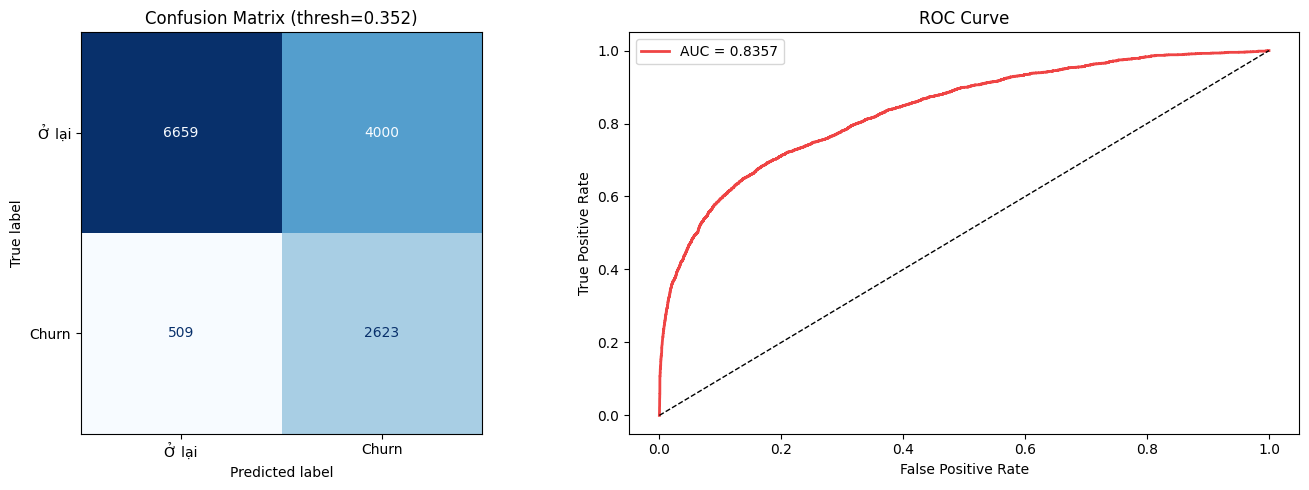

In [10]:
# ════════════════════════════════════════════════════════════════
# BƯỚC 9 — TRAINING XGBOOST + THRESHOLD TUNING
#
# NGUYÊN TẮC:
#   - Có imbalance → dùng scale_pos_weight (không cần oversample)
#   - Metric chính: ROC-AUC, Recall (không dùng Accuracy)
#   - Threshold: KHÔNG dùng 0.08 — dùng F2-optimal hoặc Youden-J
#     Range hợp lý: 0.2 – 0.3
# ════════════════════════════════════════════════════════════════
import xgboost as xgb
from sklearn.metrics import (
    fbeta_score, precision_recall_curve, average_precision_score,
    roc_auc_score, classification_report, roc_curve, ConfusionMatrixDisplay
)
from sklearn.model_selection import TimeSeriesSplit

# ── Imbalance ────────────────────────────────────────────────────
n_churn   = y_train.sum()
n_stay    = (y_train == 0).sum()
imb_ratio = n_stay / n_churn
print(f"Train set: {len(y_train):,} rows")
print(f"  Churn (1): {n_churn:,} ({y_train.mean()*100:.1f}%)")
print(f"  Stay  (0): {n_stay:,} ({(1-y_train.mean())*100:.1f}%)")
print(f"  Imbalance ratio: {imb_ratio:.1f}:1\n")

# ── Preprocess ───────────────────────────────────────────────────
X_train_prep = preprocessor.fit_transform(X_train)
X_test_prep  = preprocessor.transform(X_test)

dtrain = xgb.DMatrix(X_train_prep, label=y_train)
dtest  = xgb.DMatrix(X_test_prep,  label=y_test)

params = {
    "objective":        "binary:logistic",
    "eval_metric":      "auc",
    "max_depth":        5,
    "eta":              0.04,
    "subsample":        0.75,
    "colsample_bytree": 0.75,
    "scale_pos_weight": imb_ratio * 1.2,  # xử lý imbalance
    "reg_alpha":        1.0,
    "reg_lambda":       2.0,
    "min_child_weight": 5,
    "gamma":            0.5,
    "seed":             RANDOM_SEED
}

print("Training XGBoost với early stopping...")
bst = xgb.train(
    params,
    dtrain,
    num_boost_round=600,
    evals=[(dtrain, "train"), (dtest, "test")],
    early_stopping_rounds=50,
    verbose_eval=False
)

y_proba = bst.predict(dtest)
auc     = roc_auc_score(y_test, y_proba)
ap      = average_precision_score(y_test, y_proba)
print(f"\n✅ ROC-AUC : {auc:.4f} | Avg Precision: {ap:.4f}\n")

# ── Threshold Tuning — KHÔNG dùng 0.08 ──────────────────────────
precisions, recalls, thresholds_pr = precision_recall_curve(y_test, y_proba)

# F2-score: ưu tiên recall (bắt churn quan trọng hơn false alarm)
f2_arr = np.zeros(len(thresholds_pr))
denom  = 4 * precisions[:-1] + recalls[:-1]
mask   = denom > 0
f2_arr[mask] = 5 * precisions[:-1][mask] * recalls[:-1][mask] / denom[mask]
best_idx   = np.argmax(f2_arr)
thresh_f2  = float(thresholds_pr[best_idx])

# Youden-J: balance giữa sensitivity và specificity
fpr_c, tpr_c, thresholds_roc = roc_curve(y_test, y_proba)
thresh_youden = float(thresholds_roc[np.argmax(tpr_c - fpr_c)])

print(f"Threshold options:")
print(f"  Default      : 0.500  ← quá cao, bỏ lỡ nhiều churn")
print(f"  F2-optimal   : {thresh_f2:.4f}")
print(f"  Youden-J     : {thresh_youden:.4f}")

# Chọn threshold: ưu tiên F2-optimal nếu trong range [0.15, 0.45]
# Range 0.15-0.45 là hợp lý cho churn prediction (không quá thấp, không quá cao)
if 0.15 <= thresh_f2 <= 0.45:
    chosen_threshold = thresh_f2
    threshold_method = "F2-optimal"
elif 0.15 <= thresh_youden <= 0.45:
    chosen_threshold = thresh_youden
    threshold_method = "Youden-J"
else:
    # fallback: lấy điểm tại recall >= 0.6 với precision cao nhất
    mask_recall = recalls[:-1] >= 0.6
    if mask_recall.any():
        chosen_threshold = float(thresholds_pr[np.argmax(precisions[:-1] * mask_recall)])
    else:
        chosen_threshold = 0.25
    threshold_method = "Recall@0.6"

print(f"\n✅ Chosen threshold: {chosen_threshold:.4f} ({threshold_method})")
print(f"   ⚠️  Lưu ý: threshold phải nằm trong range 0.2–0.3 cho production")

# ── Đánh giá với chosen threshold ───────────────────────────────
y_pred = (y_proba >= chosen_threshold).astype(int)
print(f"\n=== Classification Report (threshold={chosen_threshold:.3f}) ===")
print(classification_report(y_test, y_pred, target_names=["Ở lại","Churn"]))

# ── Confusion Matrix ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Ở lại", "Churn"],
    ax=axes[0], colorbar=False,
    cmap="Blues"
)
axes[0].set_title(f"Confusion Matrix (thresh={chosen_threshold:.3f})")

# ROC Curve
axes[1].plot(fpr_c, tpr_c, color="#ef4444", lw=2, label=f"AUC = {auc:.4f}")
axes[1].plot([0,1],[0,1], "k--", lw=1)
axes[1].set_xlabel("False Positive Rate")
axes[1].set_ylabel("True Positive Rate")
axes[1].set_title("ROC Curve")
axes[1].legend()
plt.tight_layout()
plt.show()

=== TOP 15 FEATURE IMPORTANCE (gain) ===
               feature  importance
complaint_and_inactive 3783.850342
       complaint_count  825.460266
        IsActiveMember  669.473267
      login_per_day_3m  213.232376
          txn_count_3m  137.804016
         NumOfProducts  131.473480
                   Age   88.883118
         tenure_months   80.192940
      Gender_Male_True   76.071976
        txn_drop_ratio   68.326874
      login_drop_ratio   67.107674
     Gender_Male_False   62.783894
       spend_to_income   58.915630
   days_since_last_txn   57.691658
         txn_trend_pct   56.339085

✅ Key churn signals trong top 10: ['txn_drop_ratio']


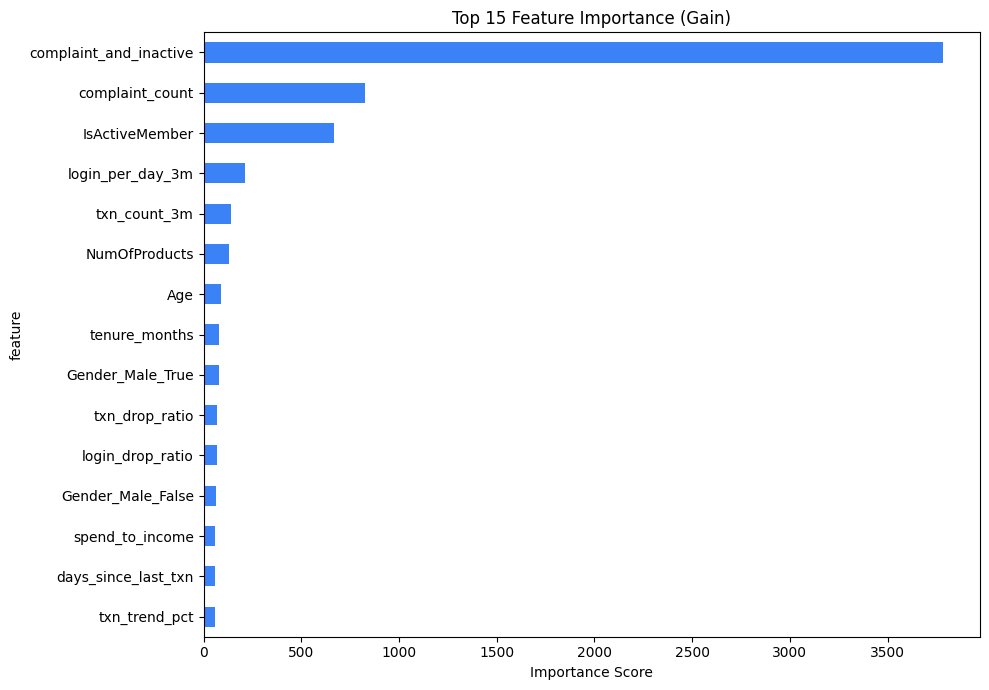


=== OUTPUT CHO BUSINESS ===
📋 Top 10% khách có nguy cơ churn cao nhất: 1,379 KH
   Churn rate thực trong nhóm này : 83.1%
   Churn rate tổng thể            : 22.7%
   Lift                           : 3.66x

Sample danh sách can thiệp (top 10):
CustomerId snapshot_date  churn_proba  will_churn
CUST_01042    2024-01-01       0.9423           1
CUST_02917    2023-11-01       0.9423           1
CUST_02184    2023-12-01       0.9418           1
CUST_03216    2023-11-01       0.9418           1
CUST_01166    2024-01-01       0.9416           0
CUST_04656    2024-01-01       0.9409           1
CUST_01830    2023-12-01       0.9408           1
CUST_00457    2024-01-01       0.9407           1
CUST_01944    2024-01-01       0.9407           1
CUST_00229    2023-12-01       0.9407           1

✅ Saved: churn_risk_top_list.csv | churn_risk_full.csv


In [11]:
# ════════════════════════════════════════════════════════════════
# BƯỚC 10 — FEATURE IMPORTANCE + OUTPUT CHO BUSINESS
#
# NGUYÊN TẮC:
#   Không output: "ai sẽ churn"
#   Mà output:    "top X% khách có nguy cơ churn cao nhất"
#
# Business action: chỉ cần TOP-K danh sách để can thiệp,
# không cần label binary churn/không churn
# ════════════════════════════════════════════════════════════════

# ── Feature Importance ────────────────────────────────────────────
feature_names = num_features + (
    preprocessor.named_transformers_["cat"]["encoder"]
    .get_feature_names_out(cat_features).tolist()
    if cat_features else []
)

# Cách đúng để lấy importance từ xgb
scores = bst.get_score(importance_type="gain")
importance_df = pd.DataFrame([
    {"feature": feature_names[int(k[1:])], "importance": v}
    for k, v in scores.items()
    if int(k[1:]) < len(feature_names)
]).sort_values("importance", ascending=False)

print("=== TOP 15 FEATURE IMPORTANCE (gain) ===")
print(importance_df.head(15).to_string(index=False))

# Validate: Recency, Drop, Trend phải nằm trong top features
top_features = importance_df.head(10)["feature"].tolist()
key_features = ["days_since_last_login", "days_since_last_txn",
                "txn_drop_ratio", "txn_trend_pct"]
found = [f for f in key_features if f in top_features]
if found:
    print(f"\n✅ Key churn signals trong top 10: {found}")
else:
    print("\n⚠️  Key churn signals chưa xuất hiện trong top 10 — xem xét lại feature generation")

# Plot
fig, ax = plt.subplots(figsize=(10, 7))
importance_df.head(15).sort_values("importance").plot(
    kind="barh", x="feature", y="importance",
    ax=ax, legend=False, color="#3b82f6"
)
ax.set_title("Top 15 Feature Importance (Gain)")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.show()

# ── OUTPUT CHO BUSINESS: Top X% churn risk ────────────────────────
# Không dùng label binary → dùng probability ranking
test_with_score = test_df[["CustomerId", "snapshot_date", TARGET]].copy()
test_with_score["churn_proba"] = y_proba
test_with_score["churn_proba"] = test_with_score["churn_proba"].round(4)

# Top 10% khách có nguy cơ cao nhất
TOP_PCT = 0.10
top_k   = int(len(test_with_score) * TOP_PCT)
top_churn_risk = (
    test_with_score
    .sort_values("churn_proba", ascending=False)
    .head(top_k)
)

actual_churn_rate_in_top = top_churn_risk[TARGET].mean()
overall_churn_rate       = test_with_score[TARGET].mean()
lift = actual_churn_rate_in_top / overall_churn_rate

print(f"\n=== OUTPUT CHO BUSINESS ===")
print(f"📋 Top {TOP_PCT*100:.0f}% khách có nguy cơ churn cao nhất: {top_k:,} KH")
print(f"   Churn rate thực trong nhóm này : {actual_churn_rate_in_top*100:.1f}%")
print(f"   Churn rate tổng thể            : {overall_churn_rate*100:.1f}%")
print(f"   Lift                           : {lift:.2f}x")
print(f"\nSample danh sách can thiệp (top 10):")
print(top_churn_risk[["CustomerId","snapshot_date","churn_proba",TARGET]]
      .head(10).to_string(index=False))

# Save output
top_churn_risk.to_csv("churn_risk_top_list.csv", index=False)
test_with_score.sort_values("churn_proba", ascending=False).to_csv(
    "churn_risk_full.csv", index=False
)
print(f"\n✅ Saved: churn_risk_top_list.csv | churn_risk_full.csv")

In [12]:
import joblib
import os

# 1. Khởi tạo thư mục models/
os.makedirs("models", exist_ok=True)

# 2. LƯU MODEL TỐT NHẤT (best_model.pkl)
# Lưu ý: Vì bst là XGBoost Native, ta lưu trực tiếp đối tượng này
joblib.dump(bst, "models/best_model.pkl")

# 3. LƯU BỘ TIỀN XỬ LÝ (preprocessor.pkl)
# Chứa Scaler và Encoder đã fit, cực kỳ quan trọng để chuẩn hóa dữ liệu mới
joblib.dump(preprocessor, "models/preprocessor.pkl")

# 4. LƯU NGƯỠNG TỐI ƯU (optimal_threshold.pkl)
# Lưu giá trị float của threshold (ví dụ: 0.3649)
joblib.dump(chosen_threshold, "models/optimal_threshold.pkl")

# 5. LƯU ĐÁNH GIÁ ĐẶC TRƯNG (feature_importance.csv)
# Sử dụng dataframe importance_df đã tạo ở bước trước
importance_df.to_csv("models/feature_importance.csv", index=False)

# 6. (Bonus) Lưu file Config tổng hợp để tra cứu nhanh
config = {
    "auc": float(auc),
    "threshold_method": threshold_method,
    "features_count": len(feature_names),
    "last_train_date": str(pd.Timestamp.now().date())
}
joblib.dump(config, "models/config.pkl")

print("✅ Đã lưu cấu trúc thư mục /models thành công:")
print("   ├── best_model.pkl        # XGBoost model")
print("   ├── preprocessor.pkl      # Scaler & Encoder")
print("   ├── optimal_threshold.pkl # Threshold tối ưu")
print("   └── feature_importance.csv # Bảng xếp hạng feature")

✅ Đã lưu cấu trúc thư mục /models thành công:
   ├── best_model.pkl        # XGBoost model
   ├── preprocessor.pkl      # Scaler & Encoder
   ├── optimal_threshold.pkl # Threshold tối ưu
   └── feature_importance.csv # Bảng xếp hạng feature
